# Inspect Ecotone/Coralis UHI HDF5 data

Point `SOURCE` at one `.h5` file or at a directory of sequential chunks. The workflow reads metadata and sampled data lazily, so a multi-gigabyte transect is not loaded into memory.

In [35]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage, display

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'ecotone_h5.py').exists():
    candidate = NOTEBOOK_DIR / 'helperscripts' / 'ecotone'
    if candidate.exists():
        NOTEBOOK_DIR = candidate
sys.path.insert(0, str(NOTEBOOK_DIR.resolve()))

import ecotone_h5
importlib.reload(ecotone_h5)  # Pick up helper edits in a running notebook kernel.

from ecotone_h5 import (
    ALTITUDE, EXTERNAL, IMU, create_rgb_gif, enhance_rgb, file_inventory, find_h5, hsi_rgb_preview,
    mean_spectrum, read_calibration, read_telemetry, rgb_frame,
    summarize_files,
)

## 1. Select a file or transect directory

In [36]:
SOURCE = Path('/media/leo/NESP_1/NTNU/UHI/Malin/2024_24_Oct_Otter_Stavøya/24_10_24/raw')
files = find_h5(SOURCE)
print(f'Found {len(files)} HDF5 file(s), totaling {sum(p.stat().st_size for p in files) / 1e9:.2f} GB')
files[:3]

Found 14 HDF5 file(s), totaling 6.93 GB


[PosixPath('/media/leo/NESP_1/NTNU/Fieldwork/UHI_Data/Slettvik_29092023/Transect3/uhi_20230929_111831_1.h5'),
 PosixPath('/media/leo/NESP_1/NTNU/Fieldwork/UHI_Data/Slettvik_29092023/Transect3/uhi_20230929_111831_2.h5'),
 PosixPath('/media/leo/NESP_1/NTNU/Fieldwork/UHI_Data/Slettvik_29092023/Transect3/uhi_20230929_111831_3.h5')]

## 2. Inventory and acquisition summary
The inventory reads names, shapes, data types, chunking, compression, and attributes—not the large arrays themselves.

In [37]:
inventory = file_inventory(files[0])
display(inventory[['path', 'kind', 'shape', 'dtype', 'chunks', 'compression']])

,path,kind,shape,dtype,chunks,compression
0,/,group,None,None,None,None
1,/rawdata,group,None,None,None,None
2,/rawdata/graph,dataset,"(1, 1)",object,"(1, 1)",None
3,/rawdata/hyperspectral,group,None,None,None,None
4,/rawdata/hyperspectral/calibration,group,None,None,None,None
5,/rawdata/hyperspectral/calibration/geometric,group,None,None,None,None
6,/rawdata/hyperspectral/calibration/geometric/f...,dataset,"(968,)",float32,None,None
7,/rawdata/hyperspectral/calibration/radiometric,group,None,None,None,None
8,/rawdata/hyperspectral/calibration/radiometric...,dataset,"(968, 416)",float32,"(968, 416)",None
9,/rawdata/hyperspectral/calibration/radiometric...,dataset,"(968, 416)",float32,"(968, 416)",None


In [38]:
summary = summarize_files(files)
display(summary)
print(f"HSI lines: {summary['hsi_lines'].sum():,}")
print(f"RGB frames: {summary['rgb_frames'].sum():,}")
print(f"UTC range: {summary['hsi_start_utc'].min()} to {summary['hsi_end_utc'].max()}")

,file,size_GB,hsi_lines,spatial_pixels,spectral_bands,hsi_start_unix,hsi_end_unix,duration_s,rgb_frames,imu_samples,altitude_samples,hsi_start_utc,hsi_end_utc
0,uhi_20230929_111831_1.h5,0.503322,443,968,416,1.695986e+09,1.695986e+09,17.725307,36,355,90,2023-09-29 11:18:31.133672714+00:00,2023-09-29 11:18:48.858980179+00:00
1,uhi_20230929_111831_2.h5,0.506584,447,968,416,1.695986e+09,1.695986e+09,17.885735,36,359,91,2023-09-29 11:18:48.899044991+00:00,2023-09-29 11:19:06.784780025+00:00
2,uhi_20230929_111831_3.h5,0.502739,447,968,416,1.695986e+09,1.695986e+09,17.885352,35,358,90,2023-09-29 11:19:06.825132847+00:00,2023-09-29 11:19:24.710485220+00:00
3,uhi_20230929_111831_4.h5,0.503322,443,968,416,1.695986e+09,1.695986e+09,17.725375,36,356,90,2023-09-29 11:19:24.750508308+00:00,2023-09-29 11:19:42.475883245+00:00
4,uhi_20230929_111831_5.h5,0.504137,444,968,416,1.695986e+09,1.695986e+09,17.765709,36,356,91,2023-09-29 11:19:42.515898227+00:00,2023-09-29 11:20:00.281607628+00:00
5,uhi_20230929_111831_6.h5,0.502740,447,968,416,1.695986e+09,1.695986e+09,17.885265,35,358,90,2023-09-29 11:20:00.321775198+00:00,2023-09-29 11:20:18.207039833+00:00
6,uhi_20230929_111831_7.h5,0.503322,443,968,416,1.695986e+09,1.695986e+09,17.725206,36,356,90,2023-09-29 11:20:18.247205019+00:00,2023-09-29 11:20:35.972411156+00:00
7,uhi_20230929_111831_8.h5,0.504955,445,968,416,1.695986e+09,1.695986e+09,17.805785,36,357,90,2023-09-29 11:20:36.012517214+00:00,2023-09-29 11:20:53.818301916+00:00
8,uhi_20230929_111831_9.h5,0.502740,447,968,416,1.695986e+09,1.695986e+09,17.885623,35,358,91,2023-09-29 11:20:53.858461618+00:00,2023-09-29 11:21:11.744084835+00:00
9,uhi_20230929_111831_10.h5,0.503322,443,968,416,1.695986e+09,1.695986e+09,17.724756,36,355,90,2023-09-29 11:21:11.784346581+00:00,2023-09-29 11:21:29.509102344+00:00


HSI lines: 6,126
RGB frames: 491
UTC range: 2023-09-29 11:18:31.133672714+00:00 to 2023-09-29 11:22:36.760948181+00:00


## 3. Instrument and calibration information

File: {'Coralis version': '1.1.1', 'File version': '1.1.0', 'Git description': 'v1.1.1-0-g48b77ee'}
Instrument: {'cameraMake': 'Ximea', 'cameraModel': 'MC023MG-SY-FL', 'cameraSerial': 'CAMAF1751004', 'cameraVersion': '206', 'spectrographMake': 'Specim', 'spectrographModel': 'V8E', 'spectrographSerial': 'V8E1124937'}
Wavelength range: 380.8568115234375 to 750.36279296875 nm
FOV range: -25.469499588012695 to 25.469499588012695


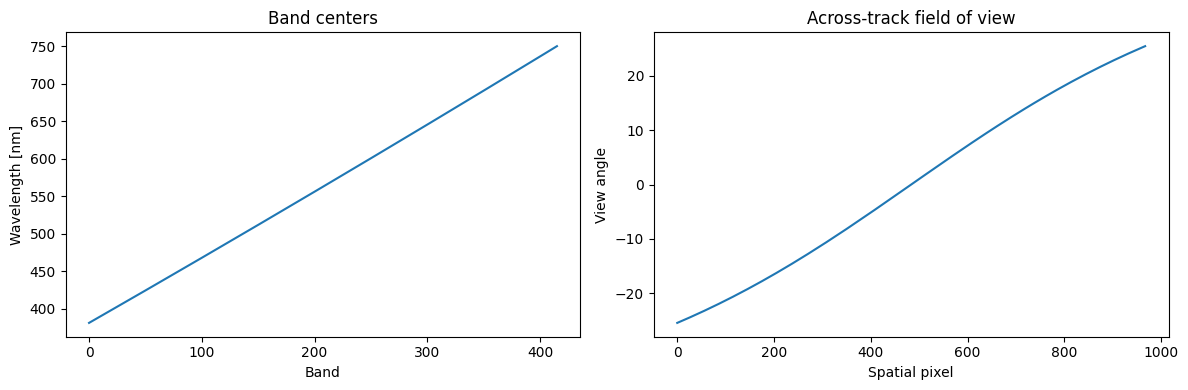

In [39]:
calibration = read_calibration(files[0])
print('File:', calibration['file_attributes'])
print('Instrument:', calibration['instrument_attributes'])
print('Wavelength range:', float(calibration['wavelength_nm'][0]), 'to', float(calibration['wavelength_nm'][-1]), 'nm')
print('FOV range:', float(np.min(calibration['field_of_view'])), 'to', float(np.max(calibration['field_of_view'])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(calibration['wavelength_nm'])
axes[0].set(title='Band centers', xlabel='Band', ylabel='Wavelength [nm]')
axes[1].plot(calibration['field_of_view'])
axes[1].set(title='Across-track field of view', xlabel='Spatial pixel', ylabel='View angle')
plt.tight_layout()

## 4. Navigation and altimeter telemetry
All chunks are concatenated and sorted by their measured Unix timestamps. These files store attitude and position in the external-navigation group rather than the IMU group.

In [40]:
navigation = read_telemetry(files, EXTERNAL)
if navigation.empty:
    navigation = read_telemetry(files, IMU)  # Compatibility with acquisitions using the IMU group.
altitude = read_telemetry(files, ALTITUDE)
display(navigation.head())
display(altitude.head())

,source_file,Heading,Pitch,PitchRate,Quaternion0,Quaternion1,Quaternion2,Quaternion3,Roll,RollRate,Temperature,TimestampMeasured,XAcceleration,XMagneticField,YAcceleration,YMagneticField,YawRate,ZAcceleration,ZMagneticField,datetime_utc
0,uhi_20230929_111831_1.h5,-176.059645,2.453018,-0.0001,-0.0005,0.9992,-0.0344,-0.0214,-0.027130,0.0052,21.1,1.695986e+09,0.4177,-0.0086,0.0070,0.2564,0.1349,9.8307,-0.9857,2023-09-29 11:18:31.135253668+00:00
1,uhi_20230929_111831_1.h5,-175.669943,2.452534,-0.0021,-0.0004,0.9991,-0.0378,-0.0214,-0.046935,0.0046,21.1,1.695986e+09,0.4155,-0.0071,0.0032,0.2564,0.1347,9.8246,-0.9852,2023-09-29 11:18:31.185272694+00:00
2,uhi_20230929_111831_1.h5,-175.278952,2.440269,-0.0036,-0.0003,0.9989,-0.0412,-0.0213,-0.066288,0.0040,21.1,1.695986e+09,0.4141,-0.0076,0.0058,0.2569,0.1346,9.8245,-0.9862,2023-09-29 11:18:31.235305786+00:00
3,uhi_20230929_111831_1.h5,-174.889548,2.451086,-0.0044,-0.0002,0.9988,-0.0446,-0.0214,-0.086551,0.0045,21.1,1.695986e+09,0.4190,-0.0026,-0.0018,0.2538,0.1330,9.8204,-0.9824,2023-09-29 11:18:31.285439491+00:00
4,uhi_20230929_111831_1.h5,-174.510084,2.450122,-0.0053,-0.0001,0.9986,-0.0479,-0.0214,-0.106127,0.0047,21.1,1.695986e+09,0.4172,-0.0017,-0.0009,0.2597,0.1329,9.8253,-0.9839,2023-09-29 11:18:31.335357189+00:00


,source_file,Altitude,Temperature,TimestampMeasured,datetime_utc
0,uhi_20230929_111831_1.h5,1.653,14.9,1.695986e+09,2023-09-29 11:18:31.173596382+00:00
1,uhi_20230929_111831_1.h5,1.665,14.9,1.695986e+09,2023-09-29 11:18:31.381194115+00:00
2,uhi_20230929_111831_1.h5,1.634,14.9,1.695986e+09,2023-09-29 11:18:31.572955847+00:00
3,uhi_20230929_111831_1.h5,1.708,14.9,1.695986e+09,2023-09-29 11:18:31.764725447+00:00
4,uhi_20230929_111831_1.h5,1.688,14.9,1.695986e+09,2023-09-29 11:18:31.972315550+00:00


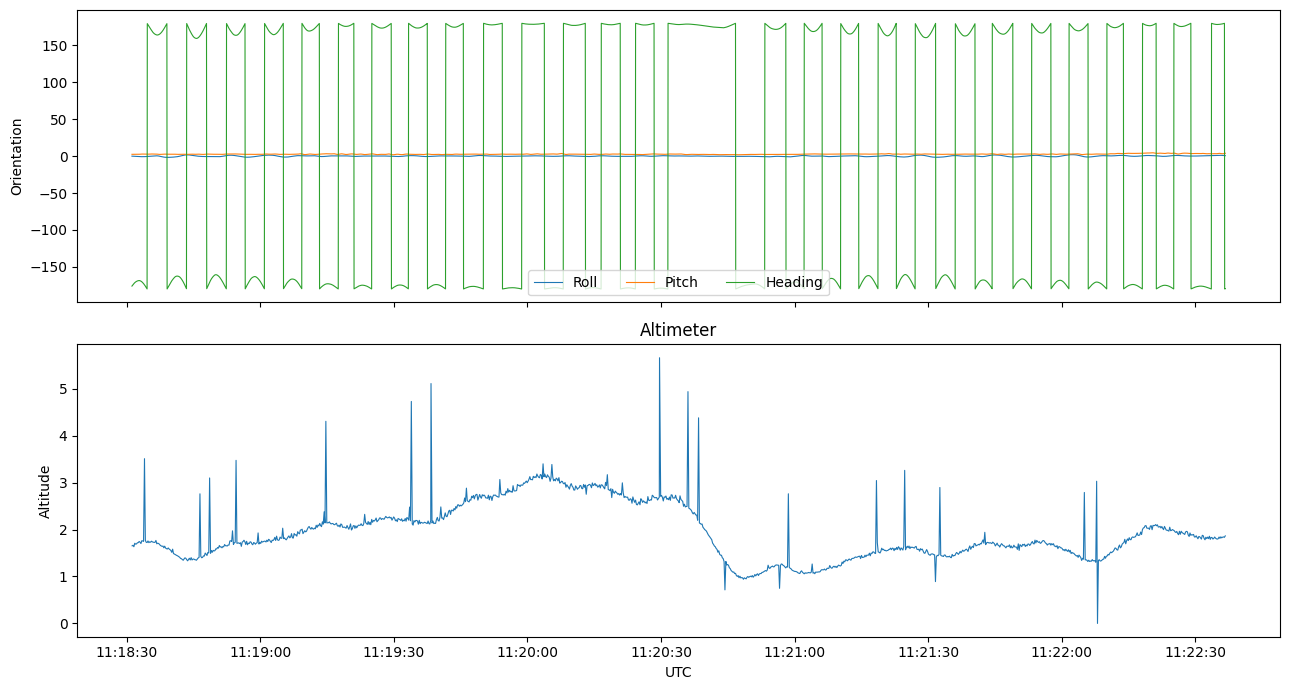

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for name in ('Roll', 'Pitch', 'Heading'):
    if name in navigation:
        axes[0].plot(navigation['datetime_utc'], navigation[name], label=name, linewidth=0.8)
axes[0].set_ylabel('Orientation')
axes[0].legend(ncol=3)
if 'Altitude' in altitude:
    axes[1].plot(altitude['datetime_utc'], altitude['Altitude'], linewidth=0.8)
axes[1].set(xlabel='UTC', ylabel='Altitude', title='Altimeter')
plt.tight_layout()

## 5. Vehicle transect map
The navigation positions saved in the HDF5 files are drawn in time order. The colour shows elapsed time, while the circle and square mark the start and end. Set `RASTER` to a georeferenced GeoTIFF (for example a DEM, orthomosaic, or RGB composite) to draw the route on top of it; leave it as `None` for a longitude/latitude plot. Raster overlays require `rasterio` and `pyproj`.

In [ ]:
RASTER = None  # Example: Path('/path/to/dem_or_orthomosaic.tif')

required = {'Longitude', 'Latitude', 'TimestampMeasured'}
missing = required.difference(navigation.columns)
if missing:
    raise KeyError(f'Navigation is missing the fields needed for a track: {sorted(missing)}')

track = navigation.dropna(subset=list(required)).copy()
track = track[track['Longitude'].between(-180, 180) & track['Latitude'].between(-90, 90)]
track = track.sort_values('TimestampMeasured', kind='stable').drop_duplicates('TimestampMeasured')
if track.empty:
    raise ValueError('No valid longitude/latitude positions were found in the selected HDF5 files')

elapsed_minutes = (track['TimestampMeasured'] - track['TimestampMeasured'].iloc[0]) / 60
x = track['Longitude'].to_numpy()
y = track['Latitude'].to_numpy()
x_label, y_label = 'Longitude [degrees]', 'Latitude [degrees]'
background = None

if RASTER is not None:
    import rasterio
    from pyproj import Transformer

    raster_path = Path(RASTER).expanduser()
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f'Raster has no coordinate reference system: {raster_path}')
        scale = min(1.0, 1600 / max(src.width, src.height))
        out_height = max(1, round(src.height * scale))
        out_width = max(1, round(src.width * scale))
        bands = [1, 2, 3] if src.count >= 3 else [1]
        background = src.read(bands, out_shape=(len(bands), out_height, out_width), masked=True)
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
        transformer = Transformer.from_crs('EPSG:4326', src.crs, always_xy=True)
        x, y = transformer.transform(x, y)
        x_label, y_label = src.crs.axis_info[0].name, src.crs.axis_info[1].name

fig, ax = plt.subplots(figsize=(11, 9))
if background is not None:
    if background.shape[0] == 1:
        ax.imshow(background[0], extent=extent, origin='upper', cmap='terrain')
    else:
        image = np.moveaxis(background.filled(np.nan), 0, -1).astype(float)
        lo, hi = np.nanpercentile(image, (2, 98), axis=(0, 1))
        image = np.clip((image - lo) / np.maximum(hi - lo, np.finfo(float).eps), 0, 1)
        ax.imshow(image, extent=extent, origin='upper')

ax.plot(x, y, color='white' if background is not None else '0.65', linewidth=3.5, zorder=2)
points = ax.scatter(x, y, c=elapsed_minutes, cmap='viridis', s=10, zorder=3)
ax.scatter(x[0], y[0], marker='o', s=100, color='lime', edgecolor='black', label='Start', zorder=4)
ax.scatter(x[-1], y[-1], marker='s', s=100, color='red', edgecolor='black', label='End', zorder=4)
fig.colorbar(points, ax=ax, label='Elapsed time [minutes]', shrink=0.75)
ax.set(title=f'Vehicle transect ({len(track):,} navigation samples)', xlabel=x_label, ylabel=y_label)
ax.legend()
if RASTER is None:
    ax.set_aspect(1 / np.cos(np.deg2rad(track['Latitude'].mean())))
else:
    ax.set_aspect('equal')
ax.grid(alpha=0.2)
plt.tight_layout()

## 6. RGB and hyperspectral previews
Only one RGB frame and three sampled HSI bands are read. The HSI preview applies the stored dark frame, radiometric frame, and per-line exposure time before percentile stretching.

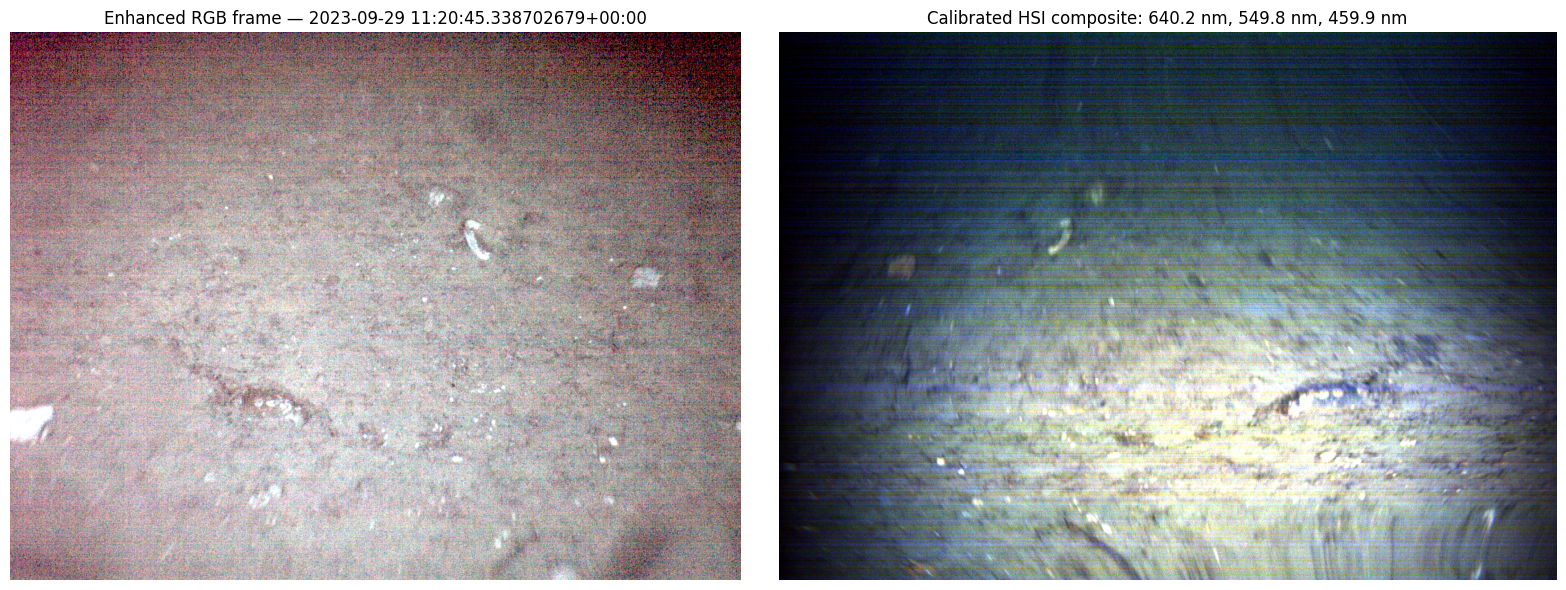

In [42]:
example_file = files[len(files) // 2]
rgb_raw, rgb_time = rgb_frame(example_file)
rgb = enhance_rgb(rgb_raw, low=1.0, high=99.5, gamma=0.65)
hsi_rgb, actual_nm = hsi_rgb_preview(example_file, targets_nm=(640, 550, 460), max_lines=500)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(rgb)
axes[0].set_title(f'Enhanced RGB frame — {pd.to_datetime(rgb_time, unit="s", utc=True)}')
axes[1].imshow(hsi_rgb, aspect='auto')
axes[1].set_title('Calibrated HSI composite: ' + ', '.join(f'{value:.1f} nm' for value in actual_nm))
for axis in axes:
    axis.axis('off')
plt.tight_layout()

## 7. RGB transect animation
Frames are sampled across every chunk, histogram-stretched, gamma-brightened, resized, and timestamped. The resulting GIF is saved locally and displayed inline. `low`, `high`, and `gamma` control the enhancement; a smaller gamma is brighter.

In [ ]:
animation_path = create_rgb_gif(
    files,
    NOTEBOOK_DIR / 'output' / 'rgb_transect_preview.gif',
    frame_step=4,
    max_frames=120,
    width=480,
    fps=8,
    enhance=True,
    low=1.0,
    high=99.5,
    gamma=0.65,
)
print(animation_path.resolve())
display(NotebookImage(filename=str(animation_path)))

## 8. Sampled radiance spectra
This samples lines and spatial pixels from each file, providing a fast transect overview rather than an exact full-cube mean.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
spectra = {}
for path in files:
    wavelength, spectrum = mean_spectrum(path, line_step=25, sample_step=16)
    spectra[path.name] = spectrum
    ax.plot(wavelength, spectrum, alpha=0.45, linewidth=0.8, label=path.stem)
ax.plot(wavelength, np.nanmean(list(spectra.values()), axis=0), color='black', linewidth=2, label='Chunk mean')
ax.set(xlabel='Wavelength [nm]', ylabel='Sampled mean radiance', title='Transect spectral overview')
ax.grid(alpha=0.2)
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

## 9. Optional export
Exports are deliberately local to this helper folder. Set `EXPORT = True` to write compact tabular/calibration products; the source HDF5 files remain untouched.

In [ ]:
EXPORT = False
if EXPORT:
    output_dir = NOTEBOOK_DIR / 'output'
    output_dir.mkdir(parents=True, exist_ok=True)
    summary.to_csv(output_dir / 'file_summary.csv', index=False)
    inventory.to_json(output_dir / 'hdf5_inventory.json', orient='records', indent=2, default_handler=str)
    navigation.to_csv(output_dir / 'navigation.csv', index=False)
    altitude.to_csv(output_dir / 'altitude.csv', index=False)
    np.savez_compressed(
        output_dir / 'calibration.npz',
        wavelength_nm=calibration['wavelength_nm'],
        field_of_view=calibration['field_of_view'],
        dark_frame=calibration['dark_frame'],
        radiometric_frame=calibration['radiometric_frame'],
    )
    pd.DataFrame(spectra, index=wavelength).rename_axis('wavelength_nm').to_csv(output_dir / 'sampled_mean_spectra.csv')
    print('Wrote', output_dir.resolve())